# 10 · PCNM Spatial Eigenvectors & Spatially-Augmented LDA

**Goal** — Determine whether adding explicit spatial information
(PCNM eigenvectors) to the environmental feature set improves
the Linear Discriminant Analysis (LDA) that classifies reference
sites into habitat clusters.

## Method overview

| Step | Description |
|------|-------------|
| 1 | Load original data, Stage 1 pollution scores, Stage 2 cluster labels (3-cluster, reference-only). |
| 2 | Merge into a single reference-site DataFrame with env variables + spatial coordinates. |
| 3 | **PCNM** (Principal Coordinates of Neighbour Matrices): compute distance-based spatial eigenvectors from site coordinates. |
| 4 | Visualise the leading PCNM eigenvectors on a map. |
| 5 | Select significant PCNM axes (positive eigenvalues + Moran's I test). |
| 6 | **Baseline LDA**: env variables only → accuracy, MCCV, Wilks' Λ. |
| 7 | **Augmented LDA**: env + selected PCNM axes → accuracy, MCCV, Wilks' Λ. |
| 8 | Compare the two models. |

In [ ]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.spatial.distance import pdist, squareform

# make sure src is importable
SRC = pathlib.Path("../src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from zci.io.readers import read_study_data, extract_block
from zci.models.clustering import TAXA_COLUMNS
from zci.core.lda import fit_lda, wilks_lambda_importance, monte_carlo_cv

print("imports ok ✓")

imports ok ✓


## 1 · Load & Merge Data

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH   = "../data/processed/complete_env_taxa_chemical_Feb_3.xlsx"
STAGE1_PATH = "../results/01_pollution_assessment/artifacts/01_updated_data.xlsx"
# Stage 2 *original* (3-cluster, reference-only, NO predicted labels)
STAGE2_PATH = "../results/02_taxa_assemblage/artifacts/02_updated_data.xlsx"

REFERENCE_QUANTILE = 0.20
ENV_VARIABLES = [
    "Measured Depth (m)",
    "Water DO Bottom (mg/L)",
    "Temperature (oC)",
    "MPS (Phi)",
    "LOI (%)",
]

# ── 1a. Read original study data ──────────────────────────────────────────────
data = read_study_data(DATA_PATH)
print(f"Original data: {data.shape[0]} sites × {data.shape[1]} columns")

# ── 1b. Extract blocks ───────────────────────────────────────────────────────
sample_info = extract_block(data, "sample_info", "raw")
env_all     = extract_block(data, "environmental", "raw")
taxa_all    = extract_block(data, "taxa", "raw")

# ── 1c. Pollution scores & reference mask ─────────────────────────────────────
stage1 = pd.read_excel(STAGE1_PATH, header=[0, 1, 2], index_col=0)
pollution_score = stage1[("01_pollution_assessment", "raw", "Pollution_Score")]
pollution_score.name = "Pollution_Score"

ref_threshold = pollution_score.quantile(REFERENCE_QUANTILE)
is_reference  = pollution_score <= ref_threshold
print(f"Reference sites (≤ {REFERENCE_QUANTILE:.0%} quantile = {ref_threshold:.3f}): {is_reference.sum()}")

# ── 1d. Cluster labels from Stage 2 (3 clusters, reference only) ─────────────
stage2 = pd.read_excel(STAGE2_PATH, header=[0, 1, 2], index_col=0)
cluster_label = stage2[("02_taxa_assemblage", "raw", "Cluster")]
cluster_label.name = "Cluster"
print(f"\nStage 2 cluster labels (non-NaN): {cluster_label.dropna().shape[0]}")
print(cluster_label.dropna().value_counts().sort_index().to_string())

# ── 1e. Build reference-site DataFrame ────────────────────────────────────────
# Align: need sites that are reference AND have a cluster label AND env + coords
ref_ids = cluster_label.dropna().index
env_ref = env_all.loc[ref_ids, ENV_VARIABLES].copy()
coords_ref = sample_info.loc[ref_ids, ["Latitude", "Longitude"]].copy()
labels_ref = cluster_label.loc[ref_ids].astype(int)

# Drop any site with NaN in env
valid = env_ref.dropna().index
env_ref    = env_ref.loc[valid]
coords_ref = coords_ref.loc[valid]
labels_ref = labels_ref.loc[valid]

print(f"\nReference sites with complete env + coords: {len(valid)}")
print(f"Cluster counts:")
print(labels_ref.value_counts().sort_index().to_string())
print(f"\nEnvironmental features ({len(ENV_VARIABLES)}):")
print(env_ref.describe().round(3).to_string())

Original data: 233 sites × 56 columns
Reference sites (≤ 20% quantile = 2.202): 47

Stage 2 cluster labels (non-NaN): 46
Cluster
1.0    35
2.0     4
3.0     7

Reference sites with complete env + coords: 46
Cluster counts:
Cluster
1    35
2     4
3     7

Environmental features (5):
var    Measured Depth (m)  Water DO Bottom (mg/L)  Temperature (oC)  MPS (Phi)  LOI (%)
count              46.000                  46.000            46.000     46.000   46.000
mean                3.166                   9.555            19.913      1.170    1.283
std                 2.159                   0.745             2.360      0.963    0.528
min                 0.400                   7.000            10.200     -1.318    0.413
25%                 1.258                   9.222            19.255      1.173    0.873
50%                 2.450                   9.725            20.065      1.536    1.201
75%                 4.600                  10.025            20.830      1.627    1.615
max         

## 2 · PCNM — Principal Coordinates of Neighbour Matrices

**PCNM** (Borcard & Legendre 2002) decomposes spatial relationships
into orthogonal eigenvectors that capture spatial structure at
different scales:

1. Compute the **Euclidean distance matrix** among site coordinates.
2. **Truncate** at a threshold *t* (typically the minimum spanning tree
   longest edge) — distances > *t* are replaced by 4 × *t*.
3. Apply **PCoA** to the truncated distance matrix → eigenvectors with
   **positive eigenvalues** represent real spatial patterns.
4. Each eigenvector is a "spatial variable" — low-order ones capture
   broad-scale patterns; high-order ones capture fine-scale patterns.

In [3]:
# ── PCNM computation ──────────────────────────────────────────────────────────
from scipy.sparse.csgraph import minimum_spanning_tree

def compute_pcnm(coords_df):
    """
    Compute PCNM eigenvectors from site coordinates.

    Parameters
    ----------
    coords_df : DataFrame with 'Latitude' and 'Longitude' columns

    Returns
    -------
    eigvals    : 1-D array of eigenvalues (all, sorted descending)
    eigvecs_df : DataFrame of eigenvectors (sites × PCNM axes), all eigenvalues
    threshold  : truncation distance (longest MST edge)
    """
    xy = coords_df[["Longitude", "Latitude"]].values  # lon/lat
    n = len(xy)

    # Step 1: Euclidean distance matrix (geographic)
    D = squareform(pdist(xy, metric="euclidean"))

    # Step 2: Truncation threshold = longest edge in MST
    mst = minimum_spanning_tree(D).toarray()
    mst_sym = mst + mst.T
    threshold = mst_sym[mst_sym > 0].max()

    # Step 3: Truncate — replace d > t  with  4*t  (Borcard & Legendre 2002)
    D_trunc = D.copy()
    D_trunc[D_trunc > threshold] = 4.0 * threshold

    # Step 4: PCoA on truncated distance matrix
    # Double-centre
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * H @ (D_trunc ** 2) @ H

    eigvals, eigvecs = np.linalg.eigh(B)
    # Sort descending
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Build DataFrame for ALL eigenvectors
    cols = [f"PCNM{i+1}" for i in range(n)]
    eigvecs_df = pd.DataFrame(eigvecs, index=coords_df.index, columns=cols)

    return eigvals, eigvecs_df, threshold


# Run PCNM
pcnm_eigvals, pcnm_eigvecs, pcnm_threshold = compute_pcnm(coords_ref)

n_positive = (pcnm_eigvals > 1e-10).sum()
n_negative = (pcnm_eigvals < -1e-10).sum()

print(f"PCNM truncation threshold: {pcnm_threshold:.6f} (degrees)")
print(f"Total eigenvectors: {len(pcnm_eigvals)}")
print(f"Positive eigenvalues: {n_positive}")
print(f"Negative eigenvalues: {n_negative}")
print(f"Variance explained by first 5 positive axes:")
pos_eigvals = pcnm_eigvals[pcnm_eigvals > 1e-10]
var_exp = pos_eigvals / pos_eigvals.sum()
for i in range(min(5, len(var_exp))):
    print(f"  PCNM{i+1}: eigenvalue={pos_eigvals[i]:.4f}, var={var_exp[i]*100:.1f}%")

PCNM truncation threshold: 0.213374 (degrees)
Total eigenvectors: 46
Positive eigenvalues: 23
Negative eigenvalues: 17
Variance explained by first 5 positive axes:
  PCNM1: eigenvalue=4.8510, var=28.8%
  PCNM2: eigenvalue=3.0242, var=17.9%
  PCNM3: eigenvalue=2.1478, var=12.7%
  PCNM4: eigenvalue=1.5709, var=9.3%
  PCNM5: eigenvalue=0.9013, var=5.3%


## 3 · Visualise Leading PCNM Eigenvectors

Each PCNM eigenvector is a "spatial pattern" — we map the first few onto
the site coordinates.  Low-order axes capture **broad-scale** gradients
(e.g. north–south, east–west); high-order axes capture **fine-scale**
patchiness.

Retained 23 positive-eigenvalue PCNM axes for analysis



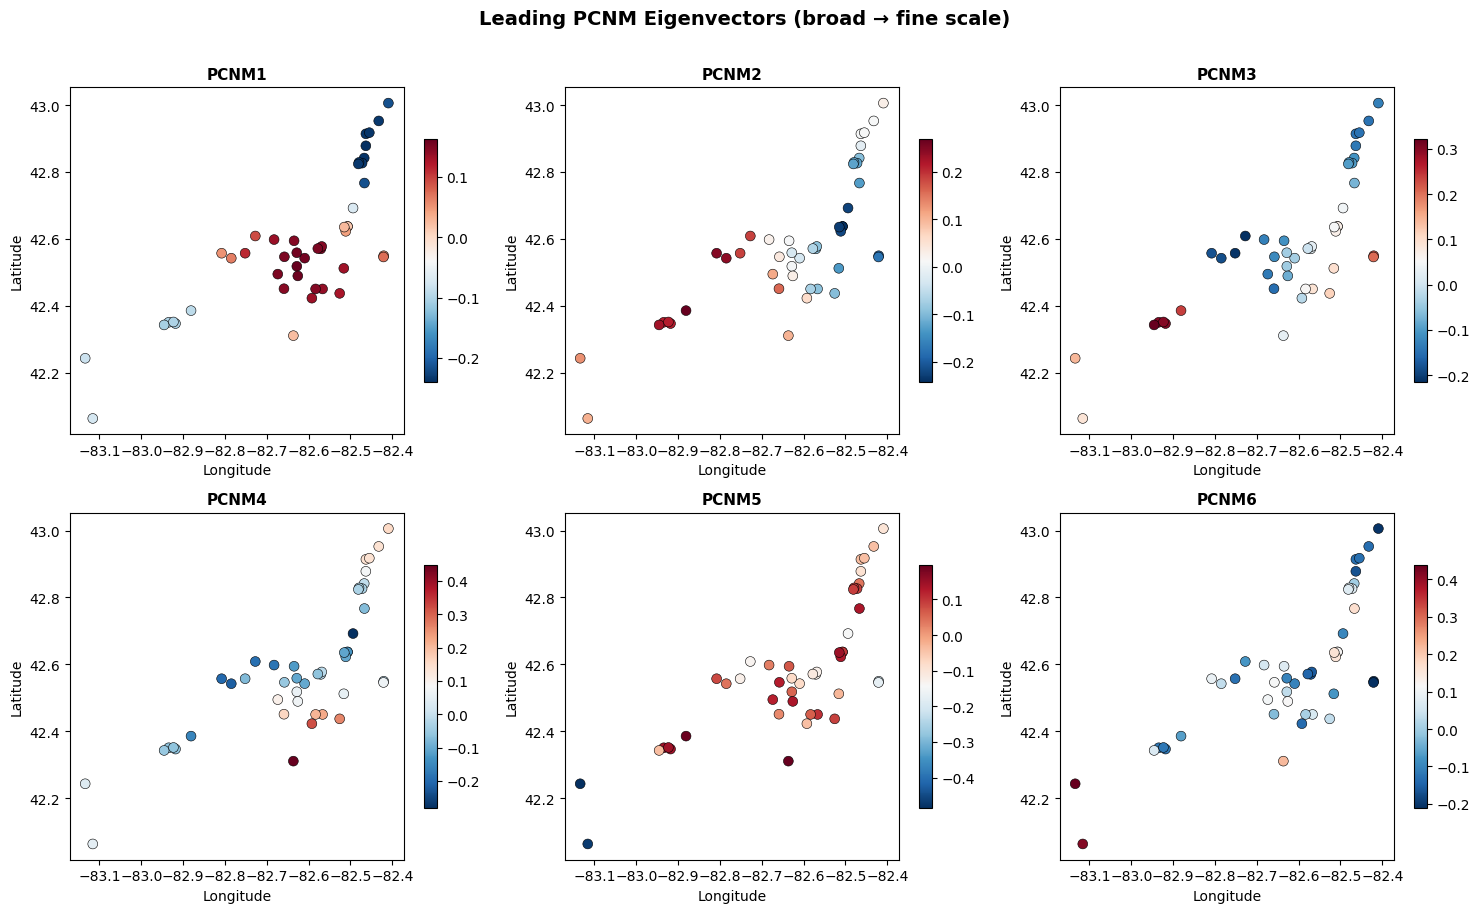

In [6]:
# ── Visualise first 6 PCNM eigenvectors on site coordinates ──────────────────
# Keep only positive-eigenvalue axes for all downstream analysis
pcnm_pos = pcnm_eigvecs.iloc[:, :n_positive]   # first n_positive columns
print(f"Retained {pcnm_pos.shape[1]} positive-eigenvalue PCNM axes for analysis\n")

n_show = min(6, pcnm_pos.shape[1])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i in range(n_show):
    ax = axes[i]
    col = pcnm_pos.columns[i]
    sc = ax.scatter(
        coords_ref["Longitude"], coords_ref["Latitude"],
        c=pcnm_pos[col], cmap="RdBu_r", edgecolors="k",
        linewidths=0.4, s=50
    )
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.colorbar(sc, ax=ax, shrink=0.7)

for j in range(n_show, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Leading PCNM Eigenvectors (broad → fine scale)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 4 · Select Meaningful PCNM Axes — Moran's I Forward Selection

Not every PCNM eigenvector carries ecologically relevant spatial structure.
We retain only those with **significant positive spatial autocorrelation**
(Moran's I > 0, tested by permutation).

> *Positive* Moran's I means nearby sites share similar scores on that axis
> — i.e. the axis describes a real spatial gradient rather than noise.

In [21]:
# ── Moran's I permutation test for each PCNM eigenvector ─────────────────────

def morans_i_permutation(values, dist_matrix, n_perm=999):
    """Compute Moran's I and assess significance via permutation."""
    n = len(values)
    x = values - values.mean()
    # inverse-distance weight matrix (zero diagonal)
    W = 1.0 / dist_matrix
    np.fill_diagonal(W, 0)
    W[~np.isfinite(W)] = 0
    W_sum = W.sum()

    # observed I
    num = n * np.dot(x, W @ x)
    denom = W_sum * np.dot(x, x)
    I_obs = num / denom if denom != 0 else 0.0

    # permutation distribution
    I_perm = np.empty(n_perm)
    for p in range(n_perm):
        xp = np.random.permutation(x)
        num_p = n * np.dot(xp, W @ xp)
        denom_p = W_sum * np.dot(xp, xp)
        I_perm[p] = num_p / denom_p if denom_p != 0 else 0.0

    p_value = ((I_perm >= I_obs).sum() + 1) / (n_perm + 1)
    return I_obs, p_value


# compute Euclidean distance matrix (raw, not truncated)
from scipy.spatial.distance import squareform, pdist
D_raw = squareform(pdist(coords_ref.values, metric="euclidean"))

np.random.seed(42)
morans_results = []
for col in pcnm_pos.columns:
    I_val, p_val = morans_i_permutation(pcnm_pos[col].values, D_raw)
    morans_results.append({"PCNM_axis": col, "Morans_I": I_val, "p_value": p_val})

morans_df = pd.DataFrame(morans_results)

# retain axes with significant positive autocorrelation
alpha = 0.05
selected_mask = (morans_df["Morans_I"] > 0.5) & (morans_df["p_value"] < alpha)
morans_df["selected"] = selected_mask

selected_pcnm_cols = morans_df.loc[selected_mask, "PCNM_axis"].tolist()

print("─── Moran's I results ───")
print(morans_df.to_string(index=False))
print(f"\n→ {len(selected_pcnm_cols)} axes selected (I > 0 & p < {alpha}):")
print(f"  {selected_pcnm_cols}")

─── Moran's I results ───
PCNM_axis  Morans_I  p_value  selected
    PCNM1  0.625808    0.001      True
    PCNM2  0.530378    0.001      True
    PCNM3  0.477541    0.001     False
    PCNM4  0.183284    0.010     False
    PCNM5  0.180259    0.007     False
    PCNM6  0.199884    0.006     False
    PCNM7  0.208441    0.004     False
    PCNM8  0.016973    0.242     False
    PCNM9 -0.103749    0.904     False
   PCNM10 -0.101162    0.878     False
   PCNM11 -0.148209    0.956     False
   PCNM12 -0.004786    0.367     False
   PCNM13 -0.225157    0.996     False
   PCNM14 -0.184620    0.976     False
   PCNM15 -0.042463    0.753     False
   PCNM16 -0.080112    0.807     False
   PCNM17 -0.158577    0.981     False
   PCNM18  0.007553    0.258     False
   PCNM19  0.080699    0.064     False
   PCNM20 -0.051180    0.731     False
   PCNM21 -0.049792    0.668     False
   PCNM22 -0.152596    0.973     False
   PCNM23 -0.166944    0.985     False

→ 2 axes selected (I > 0 & p < 0.05):

/var/folders/s5/r1s56_ps46lbbv1370hjn_vr0000gn/T/ipykernel_20425/467007102.py:8: RuntimeWarning: divide by zero encountered in divide
  W = 1.0 / dist_matrix


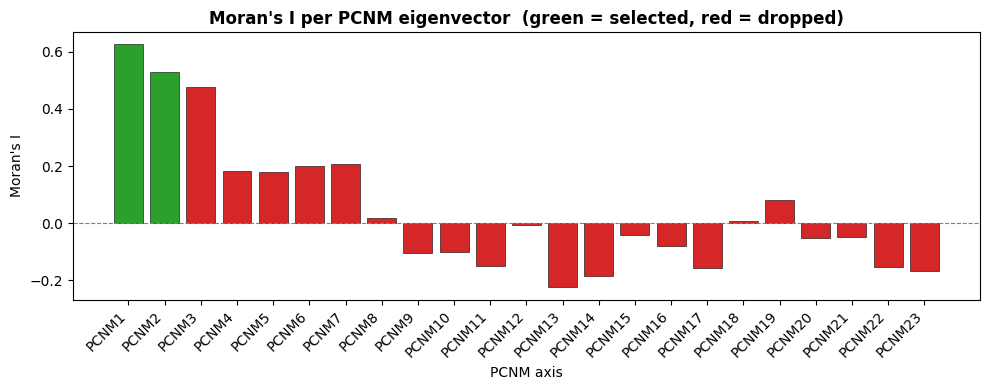

In [22]:
# ── Moran's I bar chart ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colours = ["#2ca02c" if s else "#d62728" for s in morans_df["selected"]]
ax.bar(morans_df["PCNM_axis"], morans_df["Morans_I"], color=colours,
       edgecolor="k", linewidth=0.4)
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_ylabel("Moran's I")
ax.set_xlabel("PCNM axis")
ax.set_title("Moran's I per PCNM eigenvector  (green = selected, red = dropped)",
             fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()

## 5 · Baseline LDA — Environmental Variables Only

We first fit LDA using **only** the five standard environmental variables:

| Variable | Unit |
|---|---|
| Measured Depth | m |
| Water DO Bottom | mg/L |
| Temperature | °C |
| MPS (Phi) | Φ |
| LOI | % |

This establishes the baseline classification accuracy before adding
spatial information.

In [23]:
# ── Baseline LDA (environmental features only) ───────────────────────────────

# fit LDA
lda_base = fit_lda(env_ref, labels_ref, standardize=True)

print("═══ Baseline LDA — Env Only ═══")
print(f"Training accuracy : {lda_base.accuracy:.3f}")
print(f"Explained variance: {lda_base.explained_variance_ratio}")
print(f"\nConfusion matrix:\n{lda_base.confusion_matrix}")
print(f"\nClassification report:\n{lda_base.classification_report}")

# Wilks' Lambda importance
wilks_base = wilks_lambda_importance(lda_base)
print(f"\nWilks' Λ (full)   : {wilks_base.wilks_lambda_full:.4f}")
print(f"Overall signif.   : {wilks_base.overall_significance}")
print(f"\nVariable importance:\n{wilks_base.variable_importance.to_string()}")

# Monte-Carlo cross-validation
mccv_base = monte_carlo_cv(env_ref, labels_ref, standardize=True,
                           n_iterations=1000, test_size=0.2, random_state=42)
print(f"\nMCCV accuracy (1000 iter): {mccv_base.mean_accuracy:.3f} ± {mccv_base.std_accuracy:.3f}")
print(f"  median={mccv_base.median_accuracy:.3f}  min={mccv_base.min_accuracy:.3f}  max={mccv_base.max_accuracy:.3f}")

═══ Baseline LDA — Env Only ═══
Training accuracy : 0.826
Explained variance: [0.88410347 0.11589653]

Confusion matrix:
[[31  2  2]
 [ 0  4  0]
 [ 4  0  3]]

Classification report:
{'Cluster 1': {'precision': 0.8857142857142857, 'recall': 0.8857142857142857, 'f1-score': 0.8857142857142857, 'support': 35.0}, 'Cluster 2': {'precision': 0.6666666666666666, 'recall': 1.0, 'f1-score': 0.8, 'support': 4.0}, 'Cluster 3': {'precision': 0.6, 'recall': 0.42857142857142855, 'f1-score': 0.5, 'support': 7.0}, 'accuracy': 0.8260869565217391, 'macro avg': {'precision': 0.7174603174603175, 'recall': 0.7714285714285714, 'f1-score': 0.7285714285714286, 'support': 46.0}, 'weighted avg': {'precision': 0.8231884057971015, 'recall': 0.8260869565217391, 'f1-score': 0.8195652173913044, 'support': 46.0}}

Wilks' Λ (full)   : 0.2958
Overall signif.   : {'chi_square': np.float64(49.94778053996272), 'df': 10, 'p_value': np.float64(2.7287539727804955e-07)}

Variable importance:
                        Delta Wilks

## 6 · Augmented LDA — Environmental + Spatial (PCNM) Variables

We now concatenate the selected PCNM eigenvectors with the environmental
features and re-run the same LDA pipeline.  If spatial structure carries
independent information about habitat clusters, we expect:

* **Higher resubstitution accuracy**
* **Higher MCCV accuracy** (more generalisable)
* **Lower Wilks' Λ** (better group separation)

In [24]:
# ── Augmented LDA (env + selected PCNM axes) ─────────────────────────────────

if len(selected_pcnm_cols) == 0:
    print("⚠  No PCNM axes were selected — augmented LDA is identical to baseline.")
    env_aug = env_ref.copy()
else:
    pcnm_sel = pcnm_pos[selected_pcnm_cols].copy()
    pcnm_sel.index = env_ref.index          # align index
    env_aug = pd.concat([env_ref, pcnm_sel], axis=1)

print(f"Augmented feature matrix: {env_aug.shape[0]} sites × {env_aug.shape[1]} features")
print(f"  Env columns : {list(env_ref.columns)}")
print(f"  PCNM columns: {selected_pcnm_cols}\n")

# fit LDA
lda_aug = fit_lda(env_aug, labels_ref, standardize=True)

print("═══ Augmented LDA — Env + PCNM ═══")
print(f"Training accuracy : {lda_aug.accuracy:.3f}")
print(f"Explained variance: {lda_aug.explained_variance_ratio}")
print(f"\nConfusion matrix:\n{lda_aug.confusion_matrix}")
print(f"\nClassification report:\n{lda_aug.classification_report}")

# Wilks' Lambda importance
wilks_aug = wilks_lambda_importance(lda_aug)
print(f"\nWilks' Λ (full)   : {wilks_aug.wilks_lambda_full:.4f}")
print(f"Overall signif.   : {wilks_aug.overall_significance}")
print(f"\nVariable importance:\n{wilks_aug.variable_importance.to_string()}")

# Monte-Carlo cross-validation
mccv_aug = monte_carlo_cv(env_aug, labels_ref, standardize=True,
                          n_iterations=1000, test_size=0.2, random_state=42)
print(f"\nMCCV accuracy (1000 iter): {mccv_aug.mean_accuracy:.3f} ± {mccv_aug.std_accuracy:.3f}")
print(f"  median={mccv_aug.median_accuracy:.3f}  min={mccv_aug.min_accuracy:.3f}  max={mccv_aug.max_accuracy:.3f}")

Augmented feature matrix: 46 sites × 7 features
  Env columns : ['Measured Depth (m)', 'Water DO Bottom (mg/L)', 'Temperature (oC)', 'MPS (Phi)', 'LOI (%)']
  PCNM columns: ['PCNM1', 'PCNM2']

═══ Augmented LDA — Env + PCNM ═══
Training accuracy : 0.826
Explained variance: [0.88466769 0.11533231]

Confusion matrix:
[[31  1  3]
 [ 0  4  0]
 [ 4  0  3]]

Classification report:
{'Cluster 1': {'precision': 0.8857142857142857, 'recall': 0.8857142857142857, 'f1-score': 0.8857142857142857, 'support': 35.0}, 'Cluster 2': {'precision': 0.8, 'recall': 1.0, 'f1-score': 0.8888888888888888, 'support': 4.0}, 'Cluster 3': {'precision': 0.5, 'recall': 0.42857142857142855, 'f1-score': 0.46153846153846156, 'support': 7.0}, 'accuracy': 0.8260869565217391, 'macro avg': {'precision': 0.7285714285714286, 'recall': 0.7714285714285714, 'f1-score': 0.7453805453805454, 'support': 46.0}, 'weighted avg': {'precision': 0.8195652173913044, 'recall': 0.8260869565217391, 'f1-score': 0.8214418431809737, 'support': 46.

## 7 · Comparison — Baseline vs. Augmented LDA

Side-by-side summary of all key performance metrics, plus a visual
comparison of the MCCV accuracy distributions.

In [25]:
# ── Comparison table ──────────────────────────────────────────────────────────

comp = pd.DataFrame({
    "Metric": [
        "# features",
        "Training accuracy",
        "Wilks' Λ (full)",
        "MCCV mean ± std",
        "MCCV median",
        "MCCV min",
        "MCCV max",
    ],
    "Env Only": [
        env_ref.shape[1],
        f"{lda_base.accuracy:.3f}",
        f"{wilks_base.wilks_lambda_full:.4f}",
        f"{mccv_base.mean_accuracy:.3f} ± {mccv_base.std_accuracy:.3f}",
        f"{mccv_base.median_accuracy:.3f}",
        f"{mccv_base.min_accuracy:.3f}",
        f"{mccv_base.max_accuracy:.3f}",
    ],
    "Env + PCNM": [
        env_aug.shape[1],
        f"{lda_aug.accuracy:.3f}",
        f"{wilks_aug.wilks_lambda_full:.4f}",
        f"{mccv_aug.mean_accuracy:.3f} ± {mccv_aug.std_accuracy:.3f}",
        f"{mccv_aug.median_accuracy:.3f}",
        f"{mccv_aug.min_accuracy:.3f}",
        f"{mccv_aug.max_accuracy:.3f}",
    ],
})
print("═══ Model Comparison ═══")
print(comp.to_string(index=False))

# ── Δ accuracy ────────────────────────────────────────────────────────────────
delta_train = lda_aug.accuracy - lda_base.accuracy
delta_mccv  = mccv_aug.mean_accuracy - mccv_base.mean_accuracy
print(f"\nΔ Training accuracy : {delta_train:+.3f}")
print(f"Δ MCCV mean accuracy: {delta_mccv:+.3f}")

═══ Model Comparison ═══
           Metric      Env Only    Env + PCNM
       # features             5             7
Training accuracy         0.826         0.826
  Wilks' Λ (full)        0.2958        0.2215
  MCCV mean ± std 0.799 ± 0.097 0.766 ± 0.115
      MCCV median         0.800         0.800
         MCCV min         0.400         0.300
         MCCV max         1.000         1.000

Δ Training accuracy : +0.000
Δ MCCV mean accuracy: -0.033


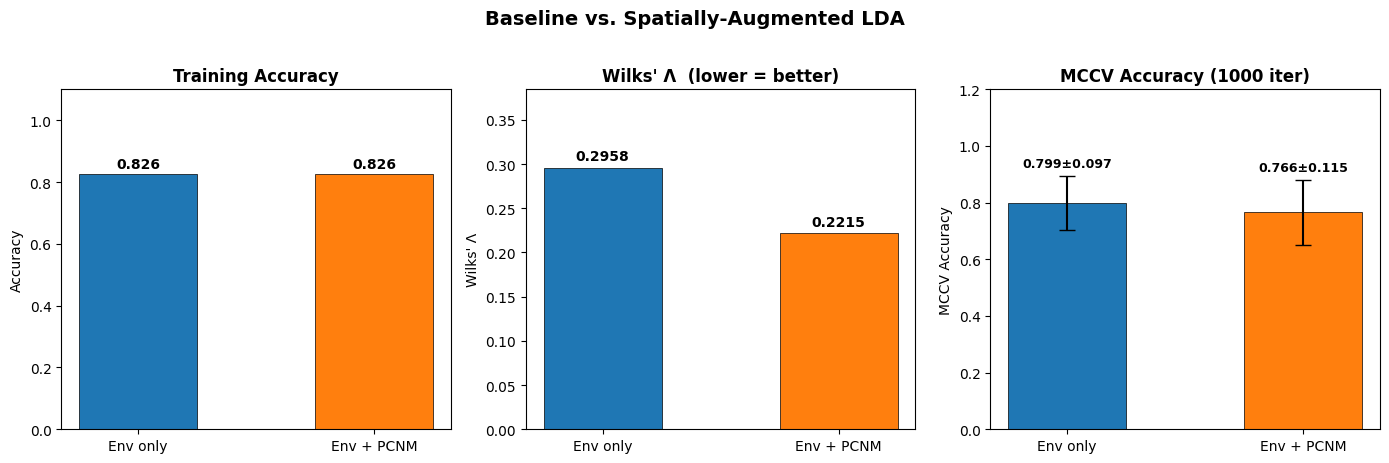

In [26]:
# ── Visual comparison: training accuracy, Wilks' Λ, MCCV ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
labels = ["Env only", "Env + PCNM"]
colours = ["#1f77b4", "#ff7f0e"]

# Panel 1: Training accuracy
ax = axes[0]
vals = [lda_base.accuracy, lda_aug.accuracy]
bars = ax.bar(labels, vals, color=colours, edgecolor="k", linewidth=0.5, width=0.5)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy")
ax.set_title("Training Accuracy", fontweight="bold")

# Panel 2: Wilks' Lambda (lower = better)
ax = axes[1]
vals = [wilks_base.wilks_lambda_full, wilks_aug.wilks_lambda_full]
bars = ax.bar(labels, vals, color=colours, edgecolor="k", linewidth=0.5, width=0.5)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.4f}",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylim(0, max(vals)*1.3)
ax.set_ylabel("Wilks' Λ")
ax.set_title("Wilks' Λ  (lower = better)", fontweight="bold")

# Panel 3: MCCV accuracy (mean ± std)
ax = axes[2]
means = [mccv_base.mean_accuracy, mccv_aug.mean_accuracy]
stds  = [mccv_base.std_accuracy, mccv_aug.std_accuracy]
bars = ax.bar(labels, means, yerr=stds, color=colours, edgecolor="k",
              linewidth=0.5, width=0.5, capsize=6)
for b, m, s in zip(bars, means, stds):
    ax.text(b.get_x() + b.get_width()/2, m + s + 0.02,
            f"{m:.3f}±{s:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=9)
ax.set_ylim(0, 1.2)
ax.set_ylabel("MCCV Accuracy")
ax.set_title("MCCV Accuracy (1000 iter)", fontweight="bold")

fig.suptitle("Baseline vs. Spatially-Augmented LDA",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()